# Modeling and Evaluation

In [20]:
# Library Imports.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Allows plots to appear directly in the notebook.
%matplotlib inline

from patsy import dmatrices
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_score 

In [21]:
# Reading from a csv file, into a data frame
df = pd.read_csv('ppr-group-25204989-train-Formodeling.csv', keep_default_na=True, delimiter=',', skipinitialspace=True)
# Show data frame first few rows
df.head(10)

,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleYear,SaleMonthIndex,Region_Encoded
0,62500.0,0,0,0,2016,7,139293.222332
1,150000.0,1,0,0,2016,12,197650.165353
2,94000.0,0,0,0,2016,8,139293.222332
3,149500.0,0,1,1,2016,2,77163.284643
4,170000.0,0,0,0,2016,10,101368.216069
5,50000.0,0,0,0,2016,12,170070.680423
6,160000.0,0,0,0,2016,12,246046.031879
7,15000.0,0,0,0,2016,10,486409.449362
8,160000.0,0,0,0,2016,8,142191.455549
9,320000.0,0,1,1,2016,12,177437.082174


In [22]:
df.dtypes

Price(€)                 float64
NotFullMarketPrice         int64
VATExclusive               int64
DescriptionofProperty      int64
SaleYear                   int64
SaleMonthIndex             int64
Region_Encoded           float64
dtype: object

In [23]:
# Look at correlations for all the continuous features. 
# As SaleYear is kept for grouping, it is excluded. The feature of time is 'SaleMonthIndex'
df[['Price(€)', 'NotFullMarketPrice', 'VATExclusive', 'DescriptionofProperty','SaleMonthIndex', 'Region_Encoded']].corr()

,Price(€),NotFullMarketPrice,VATExclusive,DescriptionofProperty,SaleMonthIndex,Region_Encoded
Price(€),1.000000,-0.137807,0.143534,0.141454,0.233328,0.632355
NotFullMarketPrice,-0.137807,1.000000,0.015873,0.017724,0.023280,-0.016786
VATExclusive,0.143534,0.015873,1.000000,0.990553,0.041120,0.122504
DescriptionofProperty,0.141454,0.017724,0.990553,1.000000,0.040821,0.121864
SaleMonthIndex,0.233328,0.023280,0.041120,0.040821,1.000000,0.332408
Region_Encoded,0.632355,-0.016786,0.122504,0.121864,0.332408,1.000000


### Notice:
The correlation table shows a problem: the correlation between VATExclusive and DescriptionofProperty is as high as 0.99, indicating that these two features are nearly identical in the information they provide to the model. In the Irish property dataset, both fields essentially act as indicators for whether a property is a "New Build" (Subject to VAT) or "Second-hand". So in the medoling section, we decide to keep VATExclusive and drop DescriptionofProperty to remove the redundant feature to simplify the model and prevent the reduction of feature importance.

<Axes: xlabel='Region_Encoded', ylabel='Price(€)'>

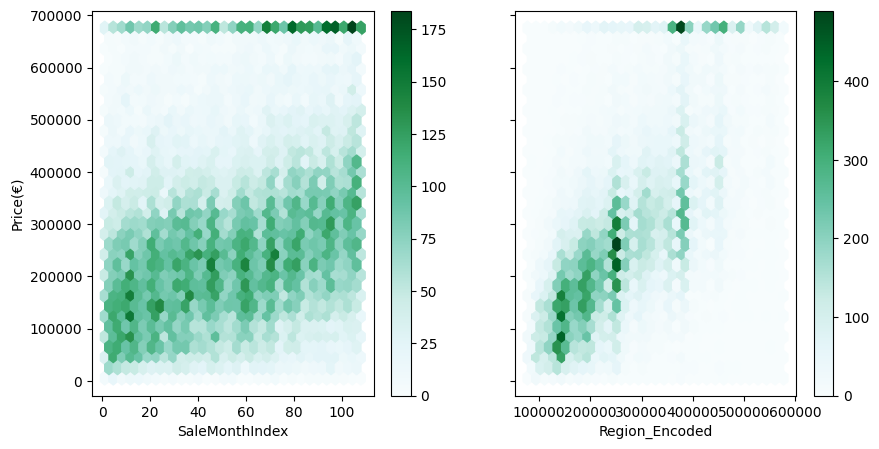

In [24]:
# As the number of samples is huge, it looks messy if we use scatter. So here we use hexbin plot to show the correlation for each continuous descriptive feature and target feature. 
fig, axs = plt.subplots(1, 2, sharey=True)
df.plot(kind='hexbin', x='SaleMonthIndex', y='Price(€)', gridsize=30,label="%.3f" %df[['SaleMonthIndex', 'Price(€)']].corr().to_numpy()[0,1], ax=axs[0], figsize=(10, 5))
df.plot(kind='hexbin', x='Region_Encoded', y='Price(€)', gridsize=30,label="%.3f" %df[['Region_Encoded', 'Price(€)']].corr().to_numpy()[0,1], ax=axs[1])

The color shows the density in the area. And the hexbin plots show that both SaleMonthIndex and Region_Encoded have a roughly linear relationship with Price.

## Preparing the data with temporal split.
As price is time related, we split the training data into 5 groups of training dataset and validation dataset by year.<br>
The first group: 2016-2019 for training, 2020 for validation.<br>
The second group: 2017-2020 for training, 2021 for validation.<br>
The third group: 2018-2021 for training, 2022 for validation.<br>
The fourth group: 2019-2022 for training, 2023 for validation.<br>
The fifth group: 2020-2023 for training, 2024 for validation.

In [25]:
# Define descriptive features and target feature
features = ['NotFullMarketPrice', 'VATExclusive', 'SaleMonthIndex', 'Region_Encoded']
target = 'Price(€)'

folds = []

# Define start_year, end_year and val_year (year for validation) of each group
group_configs = [
    (2016, 2019, 2020),
    (2017, 2020, 2021),
    (2018, 2021, 2022),
    (2019, 2022, 2023),
    (2020, 2023, 2024)
]

# start grouping
for i, (start_year, end_year, val_year) in enumerate(group_configs):
    # 1. pick out the samples of training data
    train_mask = (df['SaleYear'] >= start_year) & (df['SaleYear'] <= end_year)
    X_train = df.loc[train_mask, features]
    y_train = df.loc[train_mask, target]
    
    # 2. pick out the samples of validation data
    val_mask = df['SaleYear'] == val_year
    X_val = df.loc[val_mask, features]
    y_val = df.loc[val_mask, target]
    
    # 3. save the data set as dictionary and add into folds
    folds.append({
        'X_train': X_train,
        'y_train': y_train,
        'X_val': X_val,
        'y_val': y_val,
        'info': f"Group {i+1}: Train({start_year}-{end_year}) -> Val({val_year})"
    })
    
    print(f" {folds[i]['info']} | training data: {len(X_train)}, validation data: {len(X_val)}")

print("\nDone! Visiting the first group by folds[0]['X_train']")

 Group 1: Train(2016-2019) -> Val(2020) | training data: 23997, validation data: 6000
 Group 2: Train(2017-2020) -> Val(2021) | training data: 23998, validation data: 6000
 Group 3: Train(2018-2021) -> Val(2022) | training data: 23999, validation data: 6000
 Group 4: Train(2019-2022) -> Val(2023) | training data: 23999, validation data: 6000
 Group 5: Train(2020-2023) -> Val(2024) | training data: 24000, validation data: 5999

Done! Visiting the first group by folds[0]['X_train']


## Start modeling

### 

In [27]:
# This function is used repeatedly to compute, print and return the regression metrics
def getMetrics(testActualVal, predictions):
    mae=metrics.mean_absolute_error(testActualVal, predictions)
    rmse=metrics.mean_squared_error(testActualVal, predictions)**0.5
    r2=metrics.r2_score(testActualVal, predictions)
    print('\n==============================================================================')
    print("MAE: ", mae)
    #print("MSE: ", metrics.mean_squared_error(testActualVal, predictions))
    print("RMSE: ", rmse)
    print("R2: ", r2)
    return (mae,rmse,r2)

In [28]:
# Initialize variables for recording evaluation results
features = ['NotFullMarketPrice', 'VATExclusive', 'SaleMonthIndex', 'Region_Encoded']
results=[]

In [ ]:
# get baseline data
print('Baseline')

y=df[['Price(€)']]
baseline_pred = np.full(shape=y.shape[0], fill_value=y.mean())
(mae,rmse,r2)=getMetrics(y,baseline_pred)
results.append({
    'model':'Baseline',
    'MAE':mae,
    'RMSE':rmse,
    'R2':r2
})


MAE:  131248.71651925
RMSE:  166506.75434985722
R2:  0.0


### 1 Modeling with LinearRegression

In [29]:
# write code here

### 2 Modeling with Lasso

In [30]:
# write code here

### 3 Modeling with RidgeCV

In [31]:
from sklearn.linear_model import RidgeCV
print("Ridge")
errors={
    'MAE':[],
    'RMSE':[],
    'R2':[]
    }
for fold in folds:
    # print the info of current group
    print('='*70)
    print(fold['info'])

    # pick out the dataset
    X_train=fold['X_train']
    y_train=fold['y_train']
    X_val=fold['X_val']
    y_val=fold['y_val']

    # train the model
    ridge = RidgeCV()
    ridge.fit(X_train, y_train)

    # Print the weights learned for each feature.
    print("\nIntercept: \n", ridge.intercept_)
    print("Features and coeficients:", list(zip(features, ridge.coef_))[:10])
  
    # Predicted price on validation set
    test_predictions = ridge.predict(X_val)
    (mae,rmse,r2)=getMetrics(y_val, test_predictions)
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    feature_importance = pd.DataFrame({'feature': features, 'importance':ridge.coef_})
    display(feature_importance.sort_values('importance', ascending=False))

Ridge
Group 1: Train(2016-2019) -> Val(2020)

Intercept: 
 87369.50520998586
Features and coeficients: [('NotFullMarketPrice', np.float64(-85236.33802249617)), ('VATExclusive', np.float64(19601.139871802738)), ('SaleMonthIndex', np.float64(272.23459372270224)), ('Region_Encoded', np.float64(0.6477176214639655))]

MAE:  97516.75835974667
RMSE:  129444.56994755898
R2:  0.3466705041848578


,feature,importance
1,VATExclusive,19601.139872
2,SaleMonthIndex,272.234594
3,Region_Encoded,0.647718
0,NotFullMarketPrice,-85236.338022


Group 2: Train(2017-2020) -> Val(2021)

Intercept: 
 360685.5801310884
Features and coeficients: [('NotFullMarketPrice', np.float64(-86468.30793763458)), ('VATExclusive', np.float64(26572.582950578937)), ('SaleMonthIndex', np.float64(-194.05359431216493)), ('Region_Encoded', np.float64(-0.3887062072753906))]

MAE:  144883.52856683484
RMSE:  190446.6414528539
R2:  -0.3441960578202383


,feature,importance
1,VATExclusive,26572.582951
3,Region_Encoded,-0.388706
2,SaleMonthIndex,-194.053594
0,NotFullMarketPrice,-86468.307938


Group 3: Train(2018-2021) -> Val(2022)

Intercept: 
 -551659.0863006989
Features and coeficients: [('NotFullMarketPrice', np.float64(-94819.76423462064)), ('VATExclusive', np.float64(31445.818311839867)), ('SaleMonthIndex', np.float64(252.26093167532235)), ('Region_Encoded', np.float64(3.1506805419921875))]

MAE:  206566.0683381764
RMSE:  267263.54999580886
R2:  -1.6061756982758353


,feature,importance
1,VATExclusive,31445.818312
2,SaleMonthIndex,252.260932
3,Region_Encoded,3.150681
0,NotFullMarketPrice,-94819.764235


Group 4: Train(2019-2022) -> Val(2023)

Intercept: 
 -168483.2398811066
Features and coeficients: [('NotFullMarketPrice', np.float64(-97829.81055295699)), ('VATExclusive', np.float64(34724.226788365006)), ('SaleMonthIndex', np.float64(587.8959157303907)), ('Region_Encoded', np.float64(1.5463600158691406))]

MAE:  118198.98757102693
RMSE:  152751.4144036893
R2:  0.1405531988069656


,feature,importance
1,VATExclusive,34724.226788
2,SaleMonthIndex,587.895916
3,Region_Encoded,1.546360
0,NotFullMarketPrice,-97829.810553


Group 5: Train(2020-2023) -> Val(2024)

Intercept: 
 -58603.03464235173
Features and coeficients: [('NotFullMarketPrice', np.float64(-105837.14380251977)), ('VATExclusive', np.float64(36938.314172310056)), ('SaleMonthIndex', np.float64(246.61994379758835)), ('Region_Encoded', np.float64(1.195068359375))]

MAE:  106481.16141597967
RMSE:  135932.46052546508
R2:  0.3336590164219996


,feature,importance
1,VATExclusive,36938.314172
2,SaleMonthIndex,246.619944
3,Region_Encoded,1.195068
0,NotFullMarketPrice,-105837.143803


Intercept is the base value. Importance (coeficients)  of features means how much the feature contributes to the prediction. Take group 5 as emamples:<br>

price=-58603.03464235173+36938.314172\*VATExclusive+246.619944\*SaleMonthIndex+1.195068\*Region_Encoded+-105837.143803\*NotFullMarketPrice<br>

1,VATExclusive:36938.314172. It means if the property is VATExclusive, it adds €36938.314172 to the base value.<br>

2,SaleMonthIndex: 246.619944. It means the price grows by €246.619944 by month.<br>

3,Region_Encoded: 1.195068. It means adding 1.195068 times of the Region_Encoded value (the average price of the region in last year) to the base value.<br>

4,NotFullMarketPrice:-105837.143803. It means if the property is NotFullMarketPrice, the price declines by €105837.143803<br>

In [32]:
print('MAE:',errors['MAE'])
print('RMSE:',errors['RMSE'])
print('R2:',errors['R2'])

mean_mae=sum(errors['MAE'])/len(errors['MAE'])
mean_rmse=sum(errors['RMSE'])/len(errors['RMSE'])
mean_r2=sum(errors['R2'])/len(errors['R2'])
results.append({
    'model':'RidgeCV',
    'MAE':mean_mae,
    'RMSE':mean_rmse,
    'R2':mean_r2
})
print(results[-1])

MAE: [97516.75835974667, 144883.52856683484, 206566.0683381764, 118198.98757102693, 106481.16141597967]
RMSE: [129444.56994755898, 190446.6414528539, 267263.54999580886, 152751.4144036893, 135932.46052546508]
R2: [0.3466705041848578, -0.3441960578202383, -1.6061756982758353, 0.1405531988069656, 0.3336590164219996]
{'model': 'RidgeCV', 'MAE': 134729.3008503529, 'RMSE': 175167.72726507523, 'R2': -0.2258978073364501}


According to the error metrics, the model of RidgeCV performs awlfully in price prediction. An average value of R2 is less than 0, which means is worse than predicting with average price.<br>

This is because RidgeCV is sensitive to feature scales. Without scaling, RidgeCV applies an equal penalty to all coefficients, which disproportionately suppresses features with large numerical ranges (like Region_Encoded) while ignoring small binary ones (like VATExclusive).

In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

print("Ridge_scaled")
errors={
    'MAE':[],
    'RMSE':[],
    'R2':[]
    }
num_feature=['Region_Encoded']
binary_features=['NotFullMarketPrice', 'VATExclusive', 'SaleMonthIndex']
for fold in folds:
    # print the info of current group
    print('='*70)
    print(fold['info'])

    
    # pick out the dataset
    X_train_unscaled=fold['X_train']
    y_train=fold['y_train']
    X_val_unscaled=fold['X_val']
    y_val=fold['y_val']

    preprocess_scaled = ColumnTransformer(
    [
        ('binary', 'passthrough', binary_features),
        ('num', StandardScaler(), num_feature),
    ]
 )
    # add the code to scale here
    # fit on training data
    preprocess_scaled.fit(X_train_unscaled)

    # transform both train and validation
    X_train = preprocess_scaled.transform(X_train_unscaled)
    X_val = preprocess_scaled.transform(X_val_unscaled)

    # train the model
    ridge = RidgeCV()
    ridge.fit(X_train, y_train)

    # Print the weights learned for each feature.
    print("\nIntercept: \n", ridge.intercept_)
    print("Features and coeficients:", list(zip(features, ridge.coef_))[:10])
  
    # Predicted price on validation set
    test_predictions = ridge.predict(X_val)
    (mae,rmse,r2)=getMetrics(y_val, test_predictions)
    errors['MAE'].append(mae)
    errors['RMSE'].append(rmse)
    errors['R2'].append(r2)

    feature_importance = pd.DataFrame({'feature': features, 'importance':ridge.coef_})
    display(feature_importance.sort_values('importance', ascending=False))

Ridge_scaled
Group 1: Train(2016-2019) -> Val(2020)

Intercept: 
 239697.39553954493
Features and coeficients: [('NotFullMarketPrice', np.float64(-85236.75857278387)), ('VATExclusive', np.float64(19602.71084369299)), ('SaleMonthIndex', np.float64(272.27498621545794)), ('Region_Encoded', np.float64(99258.49301239122))]

MAE:  95315.69181726083
RMSE:  125718.66946641245
R2:  0.3837397670043713


,feature,importance
3,Region_Encoded,99258.493012
1,VATExclusive,19602.710844
2,SaleMonthIndex,272.274986
0,NotFullMarketPrice,-85236.758573


Group 2: Train(2017-2020) -> Val(2021)

Intercept: 
 265176.2041761026
Features and coeficients: [('NotFullMarketPrice', np.float64(-86468.89904077751)), ('VATExclusive', np.float64(26574.266679908047)), ('SaleMonthIndex', np.float64(-194.00971016986296)), ('Region_Encoded', np.float64(97897.3024796826))]

MAE:  96680.55947925434
RMSE:  129799.48332313802
R2:  0.37560141762674615


,feature,importance
3,Region_Encoded,97897.302480
1,VATExclusive,26574.266680
2,SaleMonthIndex,-194.009710
0,NotFullMarketPrice,-86468.899041


Group 3: Train(2018-2021) -> Val(2022)

Intercept: 
 255868.3717915308
Features and coeficients: [('NotFullMarketPrice', np.float64(-94820.3966758772)), ('VATExclusive', np.float64(31447.253361911622)), ('SaleMonthIndex', np.float64(252.28513485006988)), ('Region_Encoded', np.float64(96248.69450851495))]

MAE:  99675.77547913055
RMSE:  130833.71921336596
R2:  0.3754551954923635


,feature,importance
3,Region_Encoded,96248.694509
1,VATExclusive,31447.253362
2,SaleMonthIndex,252.285135
0,NotFullMarketPrice,-94820.396676


Group 4: Train(2019-2022) -> Val(2023)

Intercept: 
 246553.14670529752
Features and coeficients: [('NotFullMarketPrice', np.float64(-97830.34835309727)), ('VATExclusive', np.float64(34725.41952541263)), ('SaleMonthIndex', np.float64(587.9270632280968)), ('Region_Encoded', np.float64(96178.3846657396))]

MAE:  105096.19157881702
RMSE:  133323.79412313222
R2:  0.3452675779360569


,feature,importance
3,Region_Encoded,96178.384666
1,VATExclusive,34725.419525
2,SaleMonthIndex,587.927063
0,NotFullMarketPrice,-97830.348353


Group 5: Train(2020-2023) -> Val(2024)

Intercept: 
 279694.4511702168
Features and coeficients: [('NotFullMarketPrice', np.float64(-105837.76121935871)), ('VATExclusive', np.float64(36939.38653964363)), ('SaleMonthIndex', np.float64(246.68229004740715)), ('Region_Encoded', np.float64(96469.4646688737))]

MAE:  104422.58615100551
RMSE:  133135.49719123688
R2:  0.36079833410524653


,feature,importance
3,Region_Encoded,96469.464669
1,VATExclusive,36939.386540
2,SaleMonthIndex,246.682290
0,NotFullMarketPrice,-105837.761219


Take group 5 as emamples:<br>

price=279694.4511702168+36939.386540\*VATExclusive+246.682290\*SaleMonthIndex+96469.464669\*Region_Encoded-105837.761219\*NotFullMarketPrice<br>

Here Region_Encoded is scaled to [0,1]

In [35]:
print('MAE:',errors['MAE'])
print('RMSE:',errors['RMSE'])
print('R2:',errors['R2'])

mean_mae=sum(errors['MAE'])/len(errors['MAE'])
mean_rmse=sum(errors['RMSE'])/len(errors['RMSE'])
mean_r2=sum(errors['R2'])/len(errors['R2'])
results.append({
    'model':'RidgeCV_scaled',
    'MAE':mean_mae,
    'RMSE':mean_rmse,
    'R2':mean_r2
})
print(results[-1])

MAE: [95315.69181726083, 96680.55947925434, 99675.77547913055, 105096.19157881702, 104422.58615100551]
RMSE: [125718.66946641245, 129799.48332313802, 130833.71921336596, 133323.79412313222, 133135.49719123688]
R2: [0.3837397670043713, 0.37560141762674615, 0.3754551954923635, 0.3452675779360569, 0.36079833410524653]
{'model': 'RidgeCV_scaled', 'MAE': 100238.16090109365, 'RMSE': 130562.23266345709, 'R2': 0.3681724584329569}


After scaling, the performance of the model keeps stable on different groups . An average R2 of 0.368 means the model shows a moderate positive correlation. 

### 4 Modeling with Pipeline

In [ ]:
# code here

### 5 Modeling with random forest

In [ ]:
#code here